# 03 — Simulación Monte Carlo secuencial

## Objetivo

Generar múltiples escenarios financieros mediante una
simulación Monte Carlo ejecutada de forma secuencial.

En esta fase:

1. Se utilizará el modelo estadístico construido previamente.
2. Se configurará el experimento Monte Carlo.
3. Se generarán múltiples escenarios.
4. Se analizarán las trayectorias obtenidas.
5. Se analizarán los valores finales.

La implementación todavía no utiliza procesamiento paralelo.

In [39]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(
    f"Proyecto: {PROJECT_ROOT}"
)

Proyecto: c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo


In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [41]:
from src.data.loader import load_csv

from src.simulation.model import (
    NormalReturnModel,
)

from src.simulation.sequential import (
    SimulationConfig,
    simulate_sequential,
)

In [43]:
PROCESSED_DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "sp500_returns.csv"
)

returns_data = load_csv(
    PROCESSED_DATA_PATH
)

print(
    "Filas:",
    len(returns_data),
)

print(
    "Columnas:",
    list(returns_data.columns),
)

Filas: 1254
Columnas: ['observation_date', 'SP500', 'log_return']


In [44]:
returns_data.head()

,observation_date,SP500,log_return
0,2021-08-24,4486.23,0.001495
1,2021-08-25,4496.19,0.002218
2,2021-08-26,4470.00,-0.005842
3,2021-08-27,4509.37,0.008769
4,2021-08-30,4528.79,0.004297


In [45]:
mean_return = (
    returns_data["log_return"]
    .mean()
)

volatility = (
    returns_data["log_return"]
    .std()
)

print(
    f"Rendimiento medio: "
    f"{mean_return:.8f}"
)

print(
    f"Volatilidad: "
    f"{volatility:.8f}"
)

Rendimiento medio: 0.00042932
Volatilidad: 0.01072240


In [46]:
model = NormalReturnModel(
    mean=mean_return,
    volatility=volatility,
)

print(model)

NormalReturnModel(mean=np.float64(0.0004293206341343492), volatility=np.float64(0.010722404490058145))


## Configuración de la simulación

Para realizar la primera prueba utilizaremos:

- 1,000 escenarios.
- 252 periodos.
- Valor inicial de 100 unidades monetarias.
- Semilla aleatoria 42.

La semilla permite reproducir el experimento.

In [47]:
config = SimulationConfig(
    scenarios=1_000,
    horizon=252,
    initial_value=100.0,
    seed=42,
)

print(config)

SimulationConfig(scenarios=1000, horizon=252, initial_value=100.0, seed=42)


In [48]:
simulation_result = simulate_sequential(
    model=model,
    config=config,
)

print(
    type(simulation_result)
)

<class 'src.simulation.sequential.SimulationResult'>


In [49]:
print(
    dir(simulation_result)
)

['__annotations__', '__class__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__match_args__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', 'prices', 'returns']


In [51]:
print(type(simulation_result))
print(vars(simulation_result))

<class 'src.simulation.sequential.SimulationResult'>
{'returns': array([[ 0.00369662, -0.01072181,  0.00847596, ..., -0.01213269,
        -0.00351919,  0.00409162],
       [ 0.01896512, -0.01015216, -0.00220065, ...,  0.01002786,
        -0.00728524, -0.01568113],
       [-0.03135756, -0.00539826,  0.02638199, ...,  0.02239691,
         0.01957062,  0.01261049],
       ...,
       [ 0.00863   ,  0.00760562, -0.01349077, ...,  0.00765184,
         0.00988943,  0.00029397],
       [ 0.00792195, -0.01337834,  0.00965399, ..., -0.00222536,
        -0.01088871,  0.01853075],
       [-0.02300211,  0.00824037, -0.00020784, ..., -0.00619372,
        -0.00403143, -0.01327871]], shape=(1000, 252)), 'prices': array([[100.37034613,  99.29994298, 100.14518256, ...,  97.71822734,
         97.37494238,  97.77417959],
       [101.91460961, 100.88519043, 100.66342178, ..., 121.15240168,
        120.27298494, 118.40167917],
       [ 96.91289926,  96.39114796,  98.96797972, ...,  83.59479037,
         85

In [52]:
simulations = simulation_result.prices

print(
    "Tipo:",
    type(simulations),
)

print(
    "Dimensiones:",
    simulations.shape,
)

Tipo: <class 'numpy.ndarray'>
Dimensiones: (1000, 252)


In [53]:
final_values = simulations[:, -1]

print(
    "Cantidad de valores finales:",
    len(final_values),
)

print(
    "Primeros valores finales:"
)

print(
    final_values[:10]
)

Cantidad de valores finales: 1000
Primeros valores finales:
[ 97.77417959 118.40167917  86.3287182  113.23739491 106.67614722
 115.53681846  71.83331049  74.92392291 104.9919219  125.4490614 ]


In [54]:
initial_value = config.initial_value

final_returns = (
    final_values - initial_value
) / initial_value

print(
    "Primeros rendimientos finales:"
)

print(
    final_returns[:10]
)

Primeros rendimientos finales:
[-0.0222582   0.18401679 -0.13671282  0.13237395  0.06676147  0.15536818
 -0.2816669  -0.25076077  0.04991922  0.25449061]


In [55]:
print(
    f"Rendimiento promedio: "
    f"{final_returns.mean():.6f}"
)

print(
    f"Rendimiento mínimo: "
    f"{final_returns.min():.6f}"
)

print(
    f"Rendimiento máximo: "
    f"{final_returns.max():.6f}"
)

print(
    f"Desviación estándar: "
    f"{final_returns.std():.6f}"
)

Rendimiento promedio: 0.130619
Rendimiento mínimo: -0.297553
Rendimiento máximo: 0.867135
Desviación estándar: 0.194849


## Visualización de escenarios

A continuación se muestran algunas de las trayectorias
generadas por la simulación Monte Carlo.

No se muestran todos los escenarios para evitar saturar
la visualización.

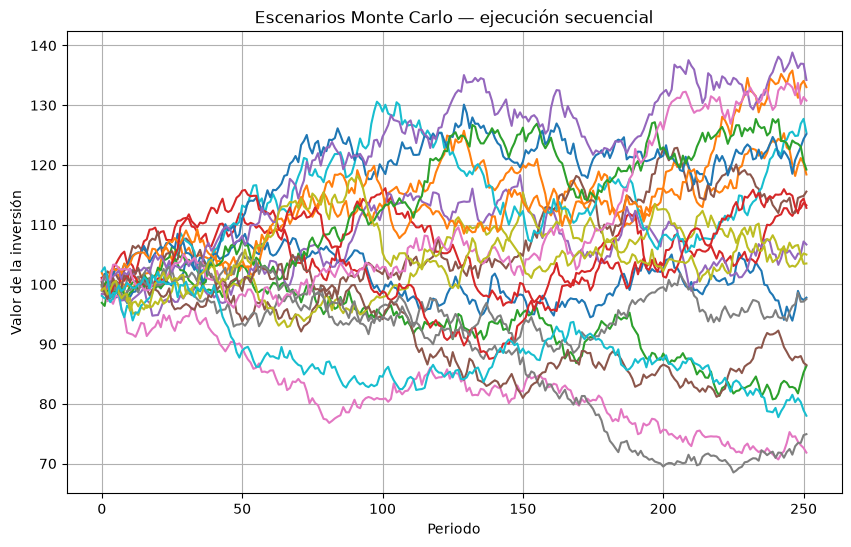

In [56]:
plt.figure(figsize=(10, 6))

number_of_paths_to_plot = 20

for scenario_index in range(
    number_of_paths_to_plot
):
    plt.plot(
        simulations[scenario_index]
    )

plt.title(
    "Escenarios Monte Carlo — ejecución secuencial"
)

plt.xlabel(
    "Periodo"
)

plt.ylabel(
    "Valor de la inversión"
)

plt.grid(True)

plt.show()

## Distribución de valores finales

La siguiente gráfica muestra cómo se distribuyen los valores
finales de la inversión entre los diferentes escenarios.

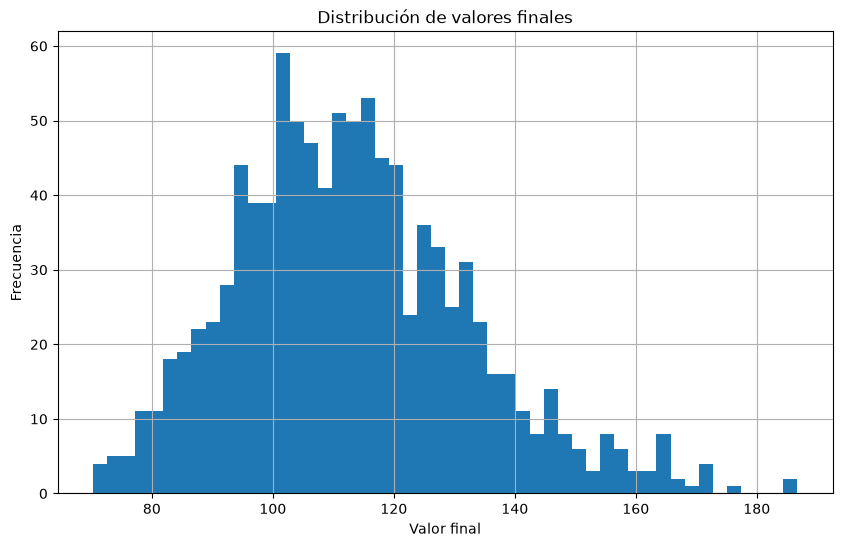

In [57]:
plt.figure(figsize=(10, 6))

plt.hist(
    final_values,
    bins=50,
)

plt.title(
    "Distribución de valores finales"
)

plt.xlabel(
    "Valor final"
)

plt.ylabel(
    "Frecuencia"
)

plt.grid(True)

plt.show()

In [58]:
loss_mask = (
    final_values < initial_value
)

probability_of_loss = (
    loss_mask.mean()
)

print(
    f"Escenarios con pérdida: "
    f"{probability_of_loss:.2%}"
)

Escenarios con pérdida: 25.70%


In [59]:
percentiles = np.percentile(
    final_values,
    [
        1,
        5,
        25,
        50,
        75,
        95,
        99,
    ],
)

percentile_table = pd.DataFrame(
    {
        "percentile": [
            "1%",
            "5%",
            "25%",
            "50%",
            "75%",
            "95%",
            "99%",
        ],
        "final_value": percentiles,
    }
)

percentile_table

,percentile,final_value
0,1%,75.038500
1,5%,84.096203
2,25%,99.489410
3,50%,111.247042
4,75%,125.064852
5,95%,147.951328
6,99%,165.746138


## Interpretación

La simulación secuencial permite generar una distribución de
posibles valores futuros bajo los supuestos establecidos por
el modelo estadístico.

Los escenarios no constituyen predicciones exactas del mercado.

Su finalidad dentro de este proyecto es estudiar cómo una gran
cantidad de simulaciones puede utilizarse para analizar el
comportamiento de una inversión bajo diferentes escenarios.

In [60]:
RESULTS_PATH = (
    PROJECT_ROOT
    / "results"
    / "tables"
    / "sequential_simulation.csv"
)

RESULTS_PATH.parent.mkdir(
    parents=True,
    exist_ok=True,
)

simulation_table = pd.DataFrame(
    {
        "final_value": final_values,
        "final_return": final_returns,
    }
)

simulation_table.to_csv(
    RESULTS_PATH,
    index=False,
)

print(
    "Resultados guardados en:"
)

print(
    RESULTS_PATH
)

Resultados guardados en:
c:\Users\REYES\OneDrive\Desktop\9noSemestre\programacion paralela\analisis riesgo montecarlo\results\tables\sequential_simulation.csv


In [61]:
print(
    "===== RESUMEN FASE 4 ====="
)

print(
    f"Escenarios: "
    f"{config.scenarios:,}"
)

print(
    f"Horizonte: "
    f"{config.horizon}"
)

print(
    f"Valor inicial: "
    f"{config.initial_value:.2f}"
)

print(
    f"Valor final promedio: "
    f"{final_values.mean():.4f}"
)

print(
    f"Probabilidad simulada de pérdida: "
    f"{probability_of_loss:.2%}"
)

===== RESUMEN FASE 4 =====
Escenarios: 1,000
Horizonte: 252
Valor inicial: 100.00
Valor final promedio: 113.0619
Probabilidad simulada de pérdida: 25.70%
